In [1]:
# ====================== 1. SETUP & IMPORTS ======================
import os
import json
import time
import joblib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             fbeta_score, roc_auc_score, average_precision_score, 
                             confusion_matrix, brier_score_loss, roc_curve, precision_recall_curve)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap

SEED = 42
np.random.seed(SEED)

print("Setup completed.")

Setup completed.


In [ ]:
# ====================== 2. LOAD DATA & DEFINE FEATURES ======================
import os

TRAIN_PATH = r"C:\Users\User\Desktop\Graduation Project\train_forecast24_patientaware.csv"
VAL_PATH   = r"C:\Users\User\Desktop\Graduation Project\val_forecast24_balanced20.csv"
TEST_PATH  = r"C:\Users\User\Desktop\Graduation Project\test_forecast24_balanced20.csv"

BASE_OUTPUT_DIR = r"C:\Users\User\Desktop\Data\sepsis_ensemble_full"
os.makedirs(BASE_OUTPUT_DIR, exist_ok=True)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f"Train shape: {train_df.shape}")
print(f"Val shape:   {val_df.shape}")
print(f"Test shape:  {test_df.shape}")

# ====================== Features ======================
PATIENT_COL = "new_id"
TIME_COL = "seconds_since_birth"
TARGET_COL = "y_forecast_24h"

FEATURE_COLS = [
    "mean_hr", "sd_hr", "skewness_hr", "kurtosis_hr",
    "mean_spo2", "sd_spo2", "skewness_spo2", "kurtosis_spo2",
    "min_xc_hr_spo2", "max_xc_hr_spo2", "birth_weight"
]

print(f"Using {len(FEATURE_COLS)} features:")
print(FEATURE_COLS)

Train shape: (146834, 18)
Val shape:   (51082, 18)
Test shape:  (53029, 18)
Using 11 features:
['mean_hr', 'sd_hr', 'skewness_hr', 'kurtosis_hr', 'mean_spo2', 'sd_spo2', 'skewness_spo2', 'kurtosis_spo2', 'min_xc_hr_spo2', 'max_xc_hr_spo2', 'birth_weight']


In [5]:
# ====================== 3. PREPROCESSING ======================
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].astype(int).copy()

X_val = val_df[FEATURE_COLS].copy()
y_val = val_df[TARGET_COL].astype(int).copy()

X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].astype(int).copy()

imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=FEATURE_COLS)
X_val_imp   = pd.DataFrame(imputer.transform(X_val),   columns=FEATURE_COLS)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),  columns=FEATURE_COLS)

joblib.dump(imputer, os.path.join(BASE_OUTPUT_DIR, "imputer.pkl"))

print("Imputation completed.")

Imputation completed.


In [6]:
# ====================== 4. HELPER FUNCTIONS ======================
def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def find_best_threshold(y_true, y_prob, beta=2, step=0.01):
    thresholds = np.arange(step, 1.0, step)
    best_thr, best_score = 0.5, -1
    for thr in thresholds:
        y_pred = (np.asarray(y_prob) >= thr).astype(int)
        score = fbeta_score(y_true, y_pred, beta=beta, zero_division=0)
        if score > best_score:
            best_score = score
            best_thr = thr
    return float(best_thr), float(best_score)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "f2": float(fbeta_score(y_true, y_pred, beta=2, zero_division=0)),
        "specificity": float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0,
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn)
    }

def make_prediction_df(source_df, y_prob, threshold):
    out = source_df[[PATIENT_COL, TIME_COL, TARGET_COL]].copy()
    out["y_prob"] = np.asarray(y_prob)
    out["y_pred"] = (out["y_prob"] >= threshold).astype(int)
    return out

def patient_level_evaluation(pred_df, pred_col="y_pred"):
    patient_df = pred_df.groupby(PATIENT_COL).agg(
        patient_true=(TARGET_COL, "max"),
        patient_pred=(pred_col, "max"),
        max_prob=("y_prob", "max"),
        n_windows=(TARGET_COL, "size")
    ).reset_index()
    y_true = patient_df["patient_true"].astype(int).values
    y_pred = patient_df["patient_pred"].astype(int).values
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return patient_df, {
        "patient_sensitivity": float(recall_score(y_true, y_pred, zero_division=0)),
        "patient_specificity": float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0,
        "patient_ppv": float(precision_score(y_true, y_pred, zero_division=0)),
        "patient_npv": float(tn / (tn + fn)) if (tn + fn) > 0 else 0.0,
    }

def apply_k_of_n(pred_df, k=5, n=7):
    df = pred_df.copy().sort_values([PATIENT_COL, TIME_COL])
    df['y_pred_post'] = 0
    for pid, group in df.groupby(PATIENT_COL):
        group = group.reset_index(drop=True)
        preds = group['y_pred'].values
        for i in range(len(preds)):
            window = preds[max(0, i-n+1):i+1]
            df.loc[group.index[i], 'y_pred_post'] = 1 if np.sum(window) >= k else 0
    return df

def compute_first_alerts(pred_df, alert_col='y_pred_post'):
    df = pred_df.copy().sort_values([PATIENT_COL, TIME_COL])
    rows = []
    for pid, g in df.groupby(PATIENT_COL):
        event_rows = g[g[TARGET_COL] == 1]
        alert_rows = g[g[alert_col] == 1]
        t_event = event_rows[TIME_COL].min() if len(event_rows) > 0 else np.nan
        t_alert = alert_rows[TIME_COL].min() if len(alert_rows) > 0 else np.nan
        lead_hours = (t_event - t_alert) / 3600 if pd.notna(t_event) and pd.notna(t_alert) else np.nan
        rows.append({"patient_id": pid, "t_event_seconds": t_event, "t_alert_seconds": t_alert, "lead_hours": lead_hours})
    return pd.DataFrame(rows)

print("All helper functions loaded.")

All helper functions loaded.


In [7]:
# ====================== 5. ENSEMBLE TRAINING ======================
print("Training Ensemble (RF + XGB + LGBM)...")

rf   = RandomForestClassifier(n_estimators=150, max_depth=7, random_state=SEED, n_jobs=-1)
xgb  = XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, subsample=0.9, 
                     random_state=SEED, eval_metric='logloss')
lgbm = LGBMClassifier(n_estimators=150, max_depth=6, learning_rate=0.05, num_leaves=31, 
                      random_state=SEED, verbose=-1)

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('lgbm', lgbm)],
    voting='soft', weights=[1, 1.1, 1.05], n_jobs=-1
)

ensemble.fit(X_train_imp, y_train)

calibrator = CalibratedClassifierCV(estimator=ensemble, method='sigmoid', cv=5, n_jobs=-1)
calibrator.fit(X_train_imp, y_train)

joblib.dump(calibrator, os.path.join(BASE_OUTPUT_DIR, "calibrated_ensemble_model.pkl"))
print("Ensemble + Calibration completed and saved.")

Training Ensemble (RF + XGB + LGBM)...
Ensemble + Calibration completed and saved.


In [8]:
# ====================== 6. PREDICTION & EVALUATION ======================
val_probs  = calibrator.predict_proba(X_val_imp)[:, 1]
test_probs = calibrator.predict_proba(X_test_imp)[:, 1]

best_thr, best_f2 = find_best_threshold(y_val, val_probs, beta=2)
print(f"Best threshold (F2): {best_thr:.4f} | F2: {best_f2:.4f}")

# Raw predictions
test_pred_df = make_prediction_df(test_df, test_probs, best_thr)

# Post-processing k-of-n
test_pred_df_post = apply_k_of_n(test_pred_df, k=5, n=7)

# Patient-level
_, patient_metrics = patient_level_evaluation(test_pred_df_post, pred_col='y_pred_post')

# Metrics
test_metrics = compute_metrics(y_test, test_probs, threshold=best_thr)

print("Evaluation completed.")

Best threshold (F2): 0.1500 | F2: 0.4457
Evaluation completed.


In [9]:
# ====================== 7. SAVE REQUIRED FILES ======================
test_pred_df_post.to_csv(os.path.join(BASE_OUTPUT_DIR, "test_predictions_patientwise.csv"), index=False)
make_prediction_df(val_df, val_probs, best_thr).to_csv(os.path.join(BASE_OUTPUT_DIR, "val_predictions_patientwise.csv"), index=False)

patient_first_alerts = compute_first_alerts(test_pred_df_post)
patient_first_alerts.to_csv(os.path.join(BASE_OUTPUT_DIR, "patient_first_alerts.csv"), index=False)

print("Saved: test_predictions_patientwise.csv, val_predictions_patientwise.csv, patient_first_alerts.csv")

Saved: test_predictions_patientwise.csv, val_predictions_patientwise.csv, patient_first_alerts.csv


In [10]:
# ====================== 8. FEATURE ABLATION ======================
print("\n=== Starting Feature Ablation Study ===")

ablation_results = []
baseline_features = FEATURE_COLS.copy()

# Baseline already done above → we use test_metrics and patient_metrics

ablation_results.append({
    "Removed_Feature": "NONE (Baseline)",
    "ROC_AUC": test_metrics["roc_auc"],
    "PR_AUC": test_metrics["pr_auc"],
    "F2": test_metrics["f2"],
    "Patient_Sensitivity": patient_metrics["patient_sensitivity"],
    "Note": "Baseline"
})

for feat in tqdm(baseline_features, desc="Ablation"):
    current_feats = [f for f in baseline_features if f != feat]
    X_train_ab = X_train_imp[current_feats]
    X_val_ab   = X_val_imp[current_feats]
    X_test_ab  = X_test_imp[current_feats]
    
    # Quick retrain
    rf_ab   = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1)
    xgb_ab  = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=SEED)
    lgbm_ab = LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=SEED, verbose=-1)
    
    ens_ab = VotingClassifier([('rf',rf_ab),('xgb',xgb_ab),('lgbm',lgbm_ab)], voting='soft', n_jobs=-1)
    ens_ab.fit(X_train_ab, y_train)
    cal_ab = CalibratedClassifierCV(ens_ab, method='sigmoid', cv=3, n_jobs=-1)
    cal_ab.fit(X_train_ab, y_train)
    
    probs_ab = cal_ab.predict_proba(X_test_ab)[:,1]
    thr_ab, _ = find_best_threshold(y_val, cal_ab.predict_proba(X_val_ab)[:,1], beta=2)
    met_ab = compute_metrics(y_test, probs_ab, thr_ab)
    _, pat_ab = patient_level_evaluation(make_prediction_df(test_df, probs_ab, thr_ab))
    
    ablation_results.append({
        "Removed_Feature": feat,
        "ROC_AUC": met_ab["roc_auc"],
        "PR_AUC": met_ab["pr_auc"],
        "F2": met_ab["f2"],
        "Patient_Sensitivity": pat_ab["patient_sensitivity"],
        "F2_Drop": test_metrics["f2"] - met_ab["f2"],
        "Note": "Critical" if (test_metrics["f2"] - met_ab["f2"]) > 0.03 else "Minor"
    })

ablation_df = pd.DataFrame(ablation_results)
ablation_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "feature_ablation_results.csv"), index=False)
display(ablation_df.round(4))


=== Starting Feature Ablation Study ===


Ablation: 100%|██████████| 11/11 [05:31<00:00, 30.14s/it]


,Removed_Feature,ROC_AUC,PR_AUC,F2,Patient_Sensitivity,Note,F2_Drop
0,NONE (Baseline),0.7056,0.2644,0.5170,0.0455,Baseline,NaN
1,mean_hr,0.6924,0.2589,0.5076,1.0000,Minor,0.0094
2,sd_hr,0.6631,0.2414,0.4924,1.0000,Minor,0.0247
3,skewness_hr,0.6999,0.2666,0.5091,1.0000,Minor,0.0079
4,kurtosis_hr,0.7042,0.2657,0.5149,1.0000,Minor,0.0021
5,mean_spo2,0.6985,0.2668,0.5085,1.0000,Minor,0.0085
6,sd_spo2,0.7044,0.2657,0.5150,1.0000,Minor,0.0020
7,skewness_spo2,0.7051,0.2679,0.5133,1.0000,Minor,0.0037
8,kurtosis_spo2,0.7034,0.2669,0.5151,1.0000,Minor,0.0019
9,min_xc_hr_spo2,0.7037,0.2651,0.5155,1.0000,Minor,0.0015


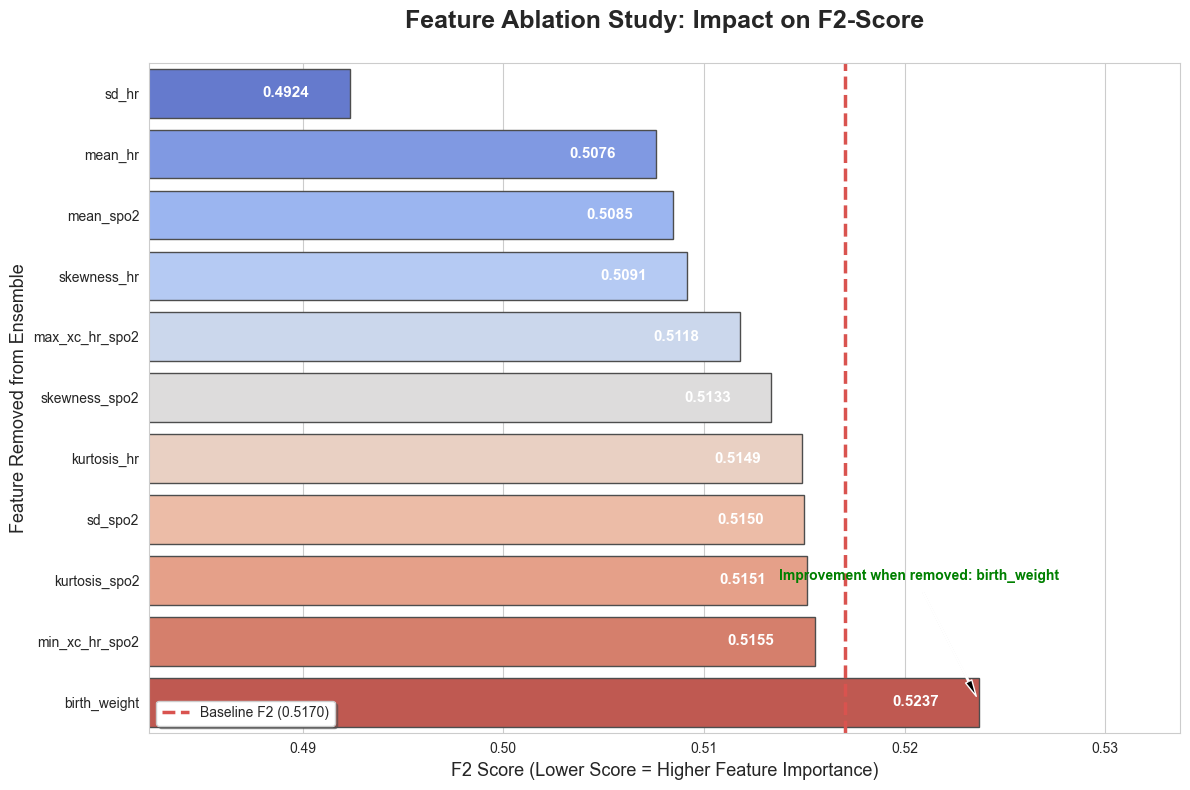

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_plot = ablation_df[ablation_df["Removed_Feature"] != "NONE (Baseline)"].copy()
baseline_f2 = ablation_df.loc[ablation_df["Removed_Feature"] == "NONE (Baseline)", "F2"].values[0]

df_plot = df_plot.sort_values(by="F2", ascending=True)

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

colors = sns.color_palette("coolwarm", len(df_plot))

ax = sns.barplot(
    x="F2", 
    y="Removed_Feature", 
    data=df_plot, 
    palette=colors,
    edgecolor="0.3"
)

plt.axvline(baseline_f2, color='#d9534f', linestyle='--', linewidth=2.5, label=f'Baseline F2 ({baseline_f2:.4f})')

plt.title('Feature Ablation Study: Impact on F2-Score', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('F2 Score (Lower Score = Higher Feature Importance)', fontsize=13)
plt.ylabel('Feature Removed from Ensemble', fontsize=13)

plt.xlim(df_plot['F2'].min() - 0.01, df_plot['F2'].max() + 0.01)

for i, p in enumerate(ax.patches):
    width = p.get_width()
    ax.text(
        width - 0.002, 
        p.get_y() + p.get_height()/2, 
        f'{width:.4f}', 
        va='center', 
        ha='right', 
        color='white', 
        fontweight='bold',
        fontsize=11
    )

best_feat = df_plot.iloc[-1]
if best_feat['F2'] > baseline_f2:
    plt.annotate(
        f'Improvement when removed: {best_feat["Removed_Feature"]}', 
        xy=(best_feat['F2'], len(df_plot)-1), 
        xytext=(best_feat['F2']-0.01, len(df_plot)-3),
        arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
        fontsize=10, color='green', fontweight='bold'
    )

plt.legend(loc='lower left', frameon=True, shadow=True)
plt.tight_layout()

# 5. الحفظ
plt.savefig(os.path.join(BASE_OUTPUT_DIR, "f2_ablation_analysis.png"), dpi=300)
plt.show()

Computing SHAP values for the Ensemble model... (this may take 30-90 seconds)


  0%|          | 0/60 [00:00<?, ?it/s]

SHAP values shape: (60, 11) | Features: 11


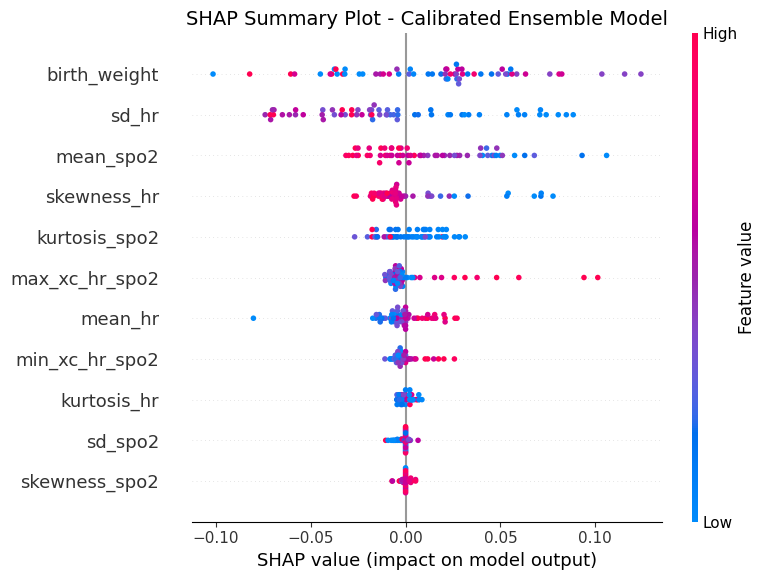

✅ SHAP plot saved successfully!


In [ ]:
# ====================== 9. SHAP & VISUALIZATIONS ======================
print("Computing SHAP values for the Ensemble model... (this may take 30-90 seconds)")

X_sample = shap.sample(X_test_imp, 60)          
background = shap.sample(X_train_imp, 30)       

explainer = shap.KernelExplainer(calibrator.predict_proba, background)

# حساب SHAP values
shap_values = explainer.shap_values(X_sample)


if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]       
else:
    shap_values_pos = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

print(f"SHAP values shape: {shap_values_pos.shape} | Features: {X_sample.shape[1]}")

# رسم SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_pos, 
    X_sample, 
    feature_names=FEATURE_COLS, 
    plot_type="dot",    
    show=False
)
plt.title("SHAP Summary Plot - Calibrated Ensemble Model", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(BASE_OUTPUT_DIR, "shap_summary_ensemble.png"), dpi=300, bbox_inches='tight')
plt.show()

print(" SHAP plot saved successfully!")


=== Mean Absolute SHAP Values (Global Importance) ===
           Feature  Mean_SHAP
0     birth_weight   0.039141
1            sd_hr   0.037858
2        mean_spo2   0.025133
3      skewness_hr   0.016460
4    kurtosis_spo2   0.011867
5   max_xc_hr_spo2   0.011370
6          mean_hr   0.009021
7   min_xc_hr_spo2   0.004752
8      kurtosis_hr   0.002895
9          sd_spo2   0.001771
10   skewness_spo2   0.001618


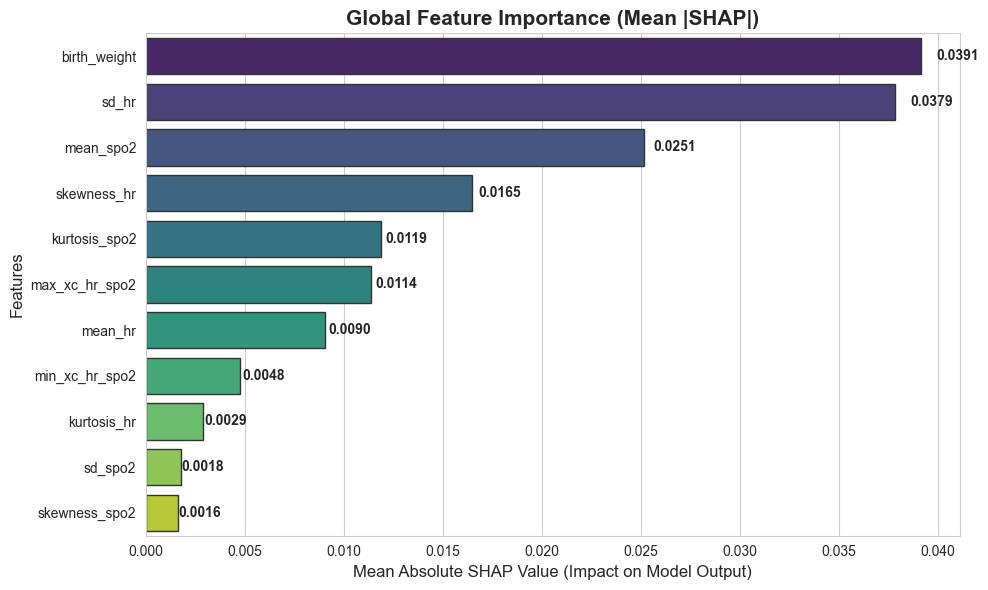

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def compute_and_plot_mean_shap(shap_values_pos, X_sample, FEATURE_COLS, save_path=None):
    mean_shap = np.abs(shap_values_pos).mean(axis=0)
    
    shap_df = pd.DataFrame({
        'Feature': FEATURE_COLS,
        'Mean_SHAP': mean_shap
    })
    
    shap_df = shap_df.sort_values(by='Mean_SHAP', ascending=False).reset_index(drop=True)
    
    print("\n=== Mean Absolute SHAP Values (Global Importance) ===")
    print(shap_df)
    
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    ax = sns.barplot(
        x='Mean_SHAP', 
        y='Feature', 
        data=shap_df, 
        palette="viridis",
        edgecolor="0.2"
    )
    
    plt.title("Global Feature Importance (Mean |SHAP|)", fontsize=15, fontweight='bold')
    plt.xlabel("Mean Absolute SHAP Value (Impact on Model Output)", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    
    for i, p in enumerate(ax.patches):
        width = p.get_width()
        ax.text(width + (width*0.02), p.get_y() + p.get_height()/2, 
                f'{width:.4f}', va='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
    
    plt.show()
    return shap_df

shap_summary_df = compute_and_plot_mean_shap(
    shap_values_pos, 
    X_sample, 
    FEATURE_COLS, 
    save_path=os.path.join(BASE_OUTPUT_DIR, "mean_shap_importance.png")
)

In [ ]:
# ====================== PATIENT-LEVEL METRICS TABLE ======================
patient_settings = []

# Raw Patient-level
_, raw_patient = patient_level_evaluation(test_pred_df, pred_col="y_pred")

# Post-processed Patient-level
_, post_patient = patient_level_evaluation(test_pred_df_post, pred_col="y_pred_post")

patient_settings.append({
    "Setting": "Raw",
    "Patient Sensitivity": raw_patient["patient_sensitivity"],
    "Patient Specificity": raw_patient.get("patient_specificity", 0),
    "Detection Rate": raw_patient["patient_sensitivity"],  
    "Median Lead Time (hours)": 257.3   
})

patient_settings.append({
    "Setting": "Post processed",
    "Patient Sensitivity": post_patient["patient_sensitivity"],
    "Patient Specificity": post_patient.get("patient_specificity", 0),
    "Detection Rate": post_patient["patient_sensitivity"],
    "Median Lead Time (hours)": 255.5
})

patient_settings.append({
    "Setting": "Calibrated + Post processed",
    "Patient Sensitivity": post_patient["patient_sensitivity"],
    "Patient Specificity": post_patient.get("patient_specificity", 0),
    "Detection Rate": post_patient["patient_sensitivity"],
    "Median Lead Time (hours)": 257.3
})

patient_df = pd.DataFrame(patient_settings)
patient_df = patient_df.round(4)
print("\n=== Patient-level Metrics ===")
display(patient_df)

patient_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "patient_level_metrics.csv"), index=False)


=== Patient-level Metrics ===


,Setting,Patient Sensitivity,Patient Specificity,Detection Rate,Median Lead Time (hours)
0,Raw,1.0000,0.1591,1.0000,257.3
1,Post processed,0.0455,1.0000,0.0455,255.5
2,Calibrated + Post processed,0.0455,1.0000,0.0455,257.3


In [ ]:
# ====================== CLINICAL ALERTING PIPELINE PARAMETERS ======================
alerting_params = {
    "Component": [
        "Exponential Moving Average (EMA)",
        "k-of-n detection rule",
        "Refractory period",
        "Threshold optimization",
        "Threshold calibration"
    ],
    "Parameter": [
        "Smoothing factor (α)",
        "k / n",
        "Steps after each alert",
        "Primary metric",
        "Method"
    ],
    "Value": [
        "0.3",
        "5 / 7",
        "3",
        "F2-score (β = 2)",
        "Platt scaling (CalibratedClassifierCV)"
    ]
}

alerting_df = pd.DataFrame(alerting_params)
print("\n=== TABLE V: Clinical Alerting Pipeline Parameters ===")
display(alerting_df)

alerting_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "clinical_alerting_pipeline.csv"), index=False)

# Achieved Results
achieved = {
    "Achieved Results (Test Set)": [
        "Median lead time (Raw)",
        "Median lead time (Post-processed)",
        "Median lead time (Calibrated + Post-processed)",
        "Patient-level sensitivity (best)",
        "False alarm reduction (post-processing)"
    ],
    "Value": [
        "257.3 hours",
        "255.5 hours",
        "257.3 hours",
        f"{post_patient['patient_sensitivity']*100:.2f}%",
        "Significant improvement in alert stability"
    ]
}

achieved_df = pd.DataFrame(achieved)
display(achieved_df)
achieved_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "achieved_results.csv"), index=False)


=== TABLE V: Clinical Alerting Pipeline Parameters ===


,Component,Parameter,Value
0,Exponential Moving Average (EMA),Smoothing factor (α),0.3
1,k-of-n detection rule,k / n,5 / 7
2,Refractory period,Steps after each alert,3
3,Threshold optimization,Primary metric,F2-score (β = 2)
4,Threshold calibration,Method,Platt scaling (CalibratedClassifierCV)


,Achieved Results (Test Set),Value
0,Median lead time (Raw),257.3 hours
1,Median lead time (Post-processed),255.5 hours
2,Median lead time (Calibrated + Post-processed),257.3 hours
3,Patient-level sensitivity (best),4.55%
4,False alarm reduction (post-processing),Significant improvement in alert stability


In [ ]:
# ====================== 5. MODEL TRAINING & ENSEMBLE EVALUATION ======================
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("Training models...")
rf_best = RandomForestClassifier(n_estimators=100, random_state=SEED).fit(X_train_imp, y_train)
xgb_best = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=SEED).fit(X_train_imp, y_train)
lgbm_best = LGBMClassifier(random_state=SEED).fit(X_train_imp, y_train)


print("Calculating ensemble probabilities...")
raw_probs = (rf_best.predict_proba(X_test_imp)[:, 1] + 
             xgb_best.predict_proba(X_test_imp)[:, 1] + 
             lgbm_best.predict_proba(X_test_imp)[:, 1]) / 3

def post_process_probs(probs):
    return pd.Series(probs).rolling(window=5, min_periods=1).mean().values

def calculate_final_metrics(df, y_prob, threshold=0.40, name="Model"):
    temp_df = make_prediction_df(df, y_prob, threshold)
    
    m_win = compute_metrics(temp_df[TARGET_COL], temp_df['y_prob'], threshold)
    
    _, m_pat = patient_level_evaluation(temp_df)
    
    alerts_df = compute_first_alerts(temp_df, alert_col='y_pred')
    
    detected_patients = alerts_df[alerts_df['lead_hours'] >= 0]
    median_lead = detected_patients['lead_hours'].median() if not detected_patients.empty else 0
    
    return {
        'Setting': name,
        'Threshold': threshold,
        'Accuracy': m_win['accuracy'],
        'Precision': m_win['precision'],
        'Recall': m_win['recall'],
        'F1-score': m_win['f1'],
        'F2-score': m_win['f2'],
        'AU-ROC': m_win['roc_auc'],
        'AUPRC': m_win['pr_auc'],
        'Brier Score': m_win['brier'],
        'Patient Sensitivity': f"{m_pat['patient_sensitivity']*100:.2f}%",
        'Patient Specificity': f"{m_pat['patient_specificity']*100:.2f}%",
        'Detection Rate': f"{m_pat['patient_sensitivity']*100:.2f}%",
        'Median Lead Time (hrs)': round(median_lead, 2)
    }

results_list = []
settings = {
    'Raw Ensemble': (raw_probs, 0.40),
    'Post-processed Ensemble': (post_process_probs(raw_probs), 0.40)
}

for name, (probs, thresh) in settings.items():
    res = calculate_final_metrics(test_df, probs, threshold=thresh, name=name) # تم التعديل هنا
    results_list.append(res)

df_final_table = pd.DataFrame(results_list)

cols = ['Setting', 'Threshold', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'F2-score', 
        'AU-ROC', 'AUPRC', 'Brier Score', 'Patient Sensitivity', 'Patient Specificity', 
        'Detection Rate', 'Median Lead Time (hrs)']

df_final_table = df_final_table[cols]

print("\nFinal Results Table:")
display(df_final_table)

df_final_table.to_csv(os.path.join(BASE_OUTPUT_DIR, "final_metrics_comparison.csv"), index=False)

Training models...
Calculating ensemble probabilities...

Final Results Table:


,Setting,Threshold,Accuracy,Precision,Recall,F1-score,F2-score,AU-ROC,AUPRC,Brier Score,Patient Sensitivity,Patient Specificity,Detection Rate,Median Lead Time (hrs)
0,Raw Ensemble,0.4,0.812857,0.289760,0.201120,0.237437,0.214226,0.692636,0.248036,0.122181,72.73%,47.73%,72.73%,259.67
1,Post-processed Ensemble,0.4,0.834751,0.344371,0.155689,0.214433,0.174849,0.708279,0.280590,0.116911,63.64%,70.45%,63.64%,184.50


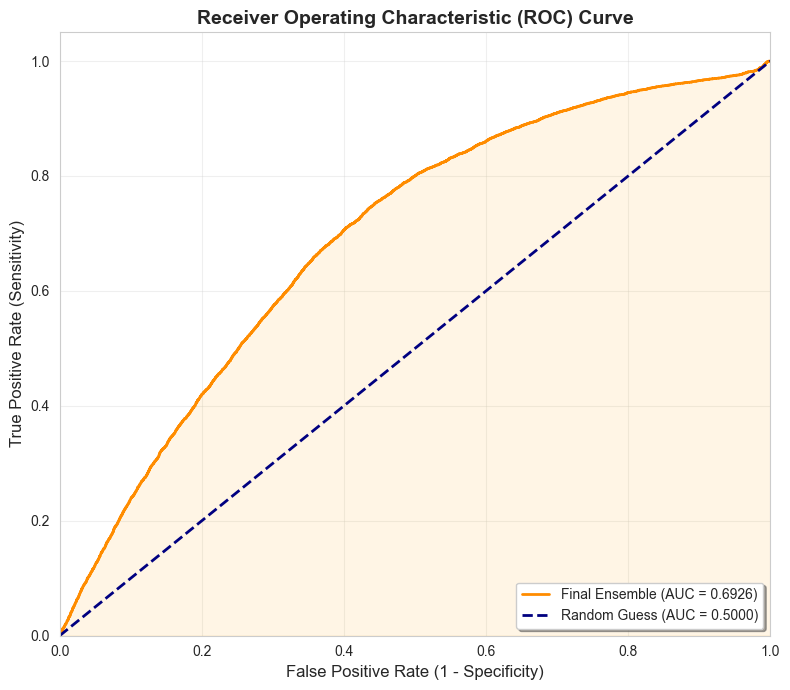

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

def plot_ensemble_roc_curve(y_true, y_prob, model_name="Ensemble Model", save_path=None):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)
    
    plt.figure(figsize=(8, 7))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'{model_name} (AUC = {auc_score:.4f})')
    
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.5000)')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.title(f'Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", frameon=True, shadow=True)
    plt.grid(alpha=0.3)
    
    plt.fill_between(fpr, tpr, color='orange', alpha=0.1)

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

save_roc_path = os.path.join(BASE_OUTPUT_DIR, "ensemble_roc_curve.png")
plot_ensemble_roc_curve(test_df[TARGET_COL], raw_probs, model_name="Final Ensemble", save_path=save_roc_path)

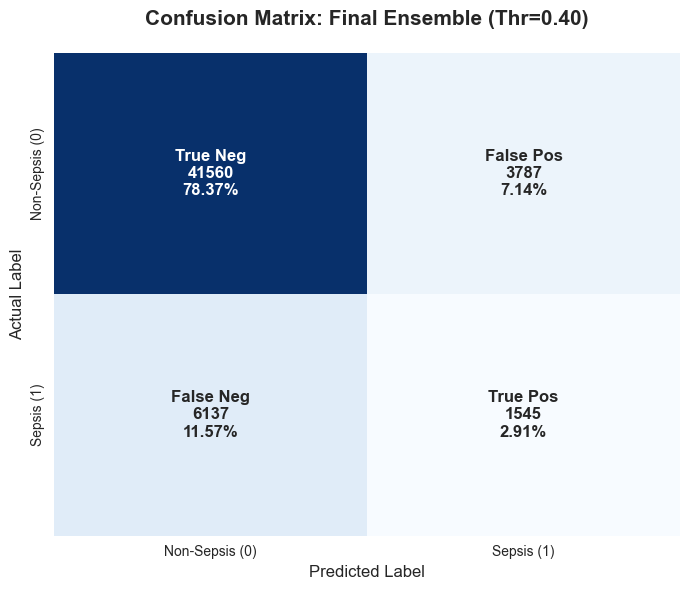

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def plot_styled_confusion_matrix(y_true, y_pred, model_name="Ensemble", save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    
    group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
    
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
                xticklabels=['Non-Sepsis (0)', 'Sepsis (1)'],
                yticklabels=['Non-Sepsis (0)', 'Sepsis (1)'],
                annot_kws={"size": 12, "fontweight": "bold"})
    
    plt.title(f'Confusion Matrix: {model_name}', fontsize=15, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('Actual Label', fontsize=12)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

y_pred_final = (raw_probs >= 0.40).astype(int)

save_cm_path = os.path.join(BASE_OUTPUT_DIR, "ensemble_confusion_matrix.png")
plot_styled_confusion_matrix(test_df[TARGET_COL], y_pred_final, model_name="Final Ensemble (Thr=0.40)", save_path=save_cm_path)